In [1]:
# The following lines enable automatic reloading of modules in an IPython/Jupyter environment.
# They work exactly like the commented lines below, but avoid errors when not running in such an environment.
# %load_ext autoreload
# %autoreload 2

try:
    # Only defined inside IPython/Jupyter
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except (NameError, AttributeError):
    # Not running in IPython → just ignore
    pass


In [2]:
# Initializing answer variable
answer = {}


In [3]:
# Some libs that we will use
import torch
import random
import numpy as np
import json_tricks
import lovely_tensors as lt
from pprint import pprint

# Making tensor printouts better
lt.monkey_patch()

# Adding sources to the pythonpath
import sys
root_path = '../../../..'
sys.path.append(root_path)

import dotenv
dotenv.load_dotenv(dotenv.find_dotenv(root_path + '/.env'))

# Importing sources of our project
import src
import src.utils as utils


# Task 0: Prepare the environment

## Goal

To make the experiment reproducible, implement `seed_all` in [src/utils/seed.py](../../../../src/utils/seed.py).

You can also use f12 key to navigate to the function definition.

## What To Seed

Inside this function, seed the random number generators used by:
- `random`
- `numpy`
- `torch`

## PyTorch Determinism

For PyTorch, seed both CPU and CUDA random number generators. Also switch cuDNN to deterministic mode with `torch.backends.cudnn.deterministic = True`. This makes repeated runs much easier to compare, especially while debugging models and tests.


In [4]:
src.utils.seed.seed_all(0)
# ^^^ This command should be edited

# Seed checks
seed_check = {
    'python.random': [random.random() for _ in range(4)],
    'python.randint': [random.randint(0, 9) for _ in range(4)],
    'numpy.random.rand': np.random.rand(2, 3),
    'numpy.random.randn': np.random.randn(2, 3),
    'numpy.random.randint': np.random.randint(0, 10, size=(2, 3)),
    'torch.rand': torch.rand(2, 3),
    'torch.randn': torch.randn(2, 3),
    'torch.randint': torch.randint(0, 10, (2, 3)),
    'torch.backends.cudnn.deterministic': torch.backends.cudnn.deterministic,
    'torch.cuda.is_available': torch.cuda.is_available(),
}

if seed_check['torch.cuda.is_available']:
    seed_check['torch.cuda.initial_seed'] = torch.cuda.initial_seed()
    seed_check['torch.cuda.rand'] = torch.rand(2, 3, device='cuda').cpu()
    seed_check['torch.cuda.randn'] = torch.randn(2, 3, device='cuda').cpu()
    seed_check['torch.cuda.randint'] = torch.randint(0, 10, (2, 3), device='cuda').cpu()

answer['seed_check'] = src.utils.detach_copy(seed_check)

print("!!! THE VALUES BELOW SHOULD BE STABLE FOR DIFFERENT RUNS !!!")
print()
pprint(seed_check)

!!! THE VALUES BELOW SHOULD BE STABLE FOR DIFFERENT RUNS !!!

{'numpy.random.rand': array([[0.5488135 , 0.71518937, 0.60276338],
       [0.54488318, 0.4236548 , 0.64589411]]),
 'numpy.random.randint': array([[8, 1, 5],
       [9, 8, 9]]),
 'numpy.random.randn': array([[ 0.95008842, -0.15135721, -0.10321885],
       [ 0.4105985 ,  0.14404357,  1.45427351]]),
 'python.randint': [8, 7, 6, 4],
 'python.random': [0.8444218515250481,
                   0.7579544029403025,
                   0.420571580830845,
                   0.25891675029296335],
 'torch.backends.cudnn.deterministic': False,
 'torch.cuda.is_available': False,
 'torch.rand': tensor[2, 3] n=6 x∈[0.088, 0.768] μ=0.404 σ=0.275 [[0.496, 0.768, 0.088], [0.132, 0.307, 0.634]],
 'torch.randint': tensor[2, 3] i64 n=6 x∈[1, 9] μ=4.500 σ=2.739 [[4, 3, 6], [9, 1, 4]],
 'torch.randn': tensor[2, 3] n=6 x∈[-0.783, 1.264] μ=0.068 σ=0.914 [[1.264, -0.687, 0.160], [-0.606, -0.783, 1.062]]}


# Training a Fully Connected Feedforward Neural Network

## Overview

In this exercise, we will train a fully connected neural network (FCNN) to classify MNIST digits into 10 classes: 0, 1, 2, ..., 9.

## Ingredients

To build and train this model, we will use:
- a fully connected neural network;
- the MNIST dataset;
- `AdamW` optimization;
- accuracy as a metric;
- cross-entropy loss, which internally combines `LogSoftmax` and negative log-likelihood.

## Why This Matters

The important part is not only the final accuracy. In this notebook, we will assemble the basic pieces that appear in almost every training pipeline: dataset, model, loss, optimizer, dataloaders, training loop, validation loop, and simple diagnostics.


# Task 1: Prepare the Dataset class

## Goal

In this task, you will implement your first dataset class for one of the most popular machine-learning datasets: MNIST.

Fill in [src/datasets/mnist_simple.py](../../../../src/datasets/mnist_simple.py) so that `MNISTSimpleDataset` works as a PyTorch-style dataset. The file should open next to this notebook.

## Methods To Implement

You need to implement three methods:
- `__init__`, the constructor;
- `__len__`, used by `len(dataset)`;
- `__getitem__`, used by `dataset[index]`.

You will use this same pattern for your own datasets later. Real datasets will often need more complicated loading and preprocessing logic, but the interface will stay the same.

## Implementation Details

- In `__init__`, load MNIST with `torchvision.datasets.MNIST`. Use the `train` argument to decide whether to load the training or validation split. Store the raw images in `self.X` and labels in `self.y`. Store the data under `~/` so that downloaded files do not clutter the repository.
- In `__len__`, return the number of samples in the dataset.
- In `__getitem__(self, index)`, return a dictionary with two keys:
    - `image`: the selected image converted to `float32` and scaled from `[0, 255]` to `[-1, 1]`;
    - `label`: the selected label converted to `long`.

## Why Scaling Helps

Scaling the image values to `[-1, 1]` keeps the inputs numerically balanced around zero. This usually makes optimization easier than feeding raw pixel values in `[0, 255]`.


In [5]:
import importlib
import src.datasets.mnist_simple
importlib.reload(src.datasets.mnist_simple)
from src.datasets.mnist_simple import MNISTSimpleDataset

# Теперь создаём объекты заново
MNIST_train = MNISTSimpleDataset(train=True)
MNIST_valid = MNISTSimpleDataset(train=False)

In [6]:
#import os
#import torch
#import numpy as np
#import torchvision.datasets
#
#class MNISTSimpleDataset:
#    def __init__(self, train=True):
#        root = os.path.expanduser('~/')
#        dataset = torchvision.datasets.MNIST(root=root, train=train, download=True)
#        self.X = np.array([np.array(dataset[i][0]) for i in range(len(dataset))], dtype=np.uint8)
#        self.y = np.array([dataset[i][1] for i in range(len(dataset))], dtype=np.int64)
#
#    def __len__(self):
#        return len(self.X)
#
#    def __getitem__(self, index):
#        image = self.X[index].astype(np.float32)
#        image = (image / 127.5) - 1.0
#        label = self.y[index]
#        return {
#            'image': torch.from_numpy(image),
#            'label': torch.tensor(label, dtype=torch.long)
#        }
#
#MNIST_train = MNISTSimpleDataset(train=True)
#MNIST_valid = MNISTSimpleDataset(train=False)

#sample = MNIST_train[0]
#print(sample.keys()) 
#print(sample['image'].shape)
#

Check that the data is prepared:

In [7]:
train_sample = MNIST_train[0]
valid_sample = MNIST_valid[0]

X_train = train_sample['image']
X_valid = valid_sample['image']
y_train = train_sample['label']
y_valid = valid_sample['label']


In [8]:
## This checks are for dataset verification
answer['X_train.dtype'] = str(X_train.dtype)
answer['y_train.dtype'] = str(y_train.dtype)
answer['X_valid.dtype'] = str(X_valid.dtype)
answer['y_valid.dtype'] = str(y_valid.dtype)
answer['X_train.shape'] = X_train.shape
answer['X_valid.shape'] = X_valid.shape
answer['y_train.shape'] = y_train.shape
answer['y_valid.shape'] = y_valid.shape
answer['X_train.mean'] = float(X_train.mean())
answer['y_train.mean'] = float(y_train.float().mean())
answer['X_valid.mean'] = float(X_valid.mean())
answer['y_valid.mean'] = float(y_valid.float().mean())

print('\nX_train dtype:', X_train.dtype, '\nX_valid dtype:', X_valid.dtype, '\ny_train dtype', y_train.dtype, '\ny_valid dtype:', y_valid.dtype)
print('\nX_train shape:', X_train.shape, '\nX_valid shape', X_valid.shape, '\ny_train shape:', y_train.shape, '\ny_valid shape:', y_valid.shape)

print()
print('X train:', X_train)
print('X_valid:', X_valid)
print('y_train:', y_train)
print('y_valid:', y_valid)



X_train dtype: torch.float32 
X_valid dtype: torch.float32 
y_train dtype torch.int64 
y_valid dtype: torch.int64

X_train shape: torch.Size([28, 28]) 
X_valid shape torch.Size([28, 28]) 
y_train shape: torch.Size([]) 
y_valid shape: torch.Size([])

X train: tensor[28, 28] n=784 (3.1Kb) x∈[-1.000, 1.000] μ=-0.725 σ=0.625
X_valid: tensor[28, 28] n=784 (3.1Kb) x∈[-1.000, 1.000] μ=-0.815 σ=0.518
y_train: tensor i64 5
y_valid: tensor i64 7


Neural networks are usually trained with floating-point tensors, most commonly `float32` or `float16`. In this exercise, the dataset class should return images as `float32` tensors.


Let us visualize one training sample.


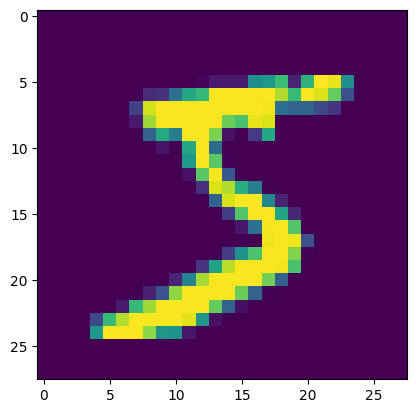

tensor i64 5


In [9]:
import matplotlib.pyplot as plt
plt.imshow(X_train)
plt.show()
print(y_train)


## Batch Updating Protocol

## Motivation

Before we build the model, let us agree on how information moves through the training pipeline. A dataset item starts as a small dictionary, for example `{"image": ..., "label": ...}`. When the dataloader combines many items into a mini-batch, the training loop wraps that batch into a nested dictionary:

```python
batch = {'data': original_batch}
```

## Batch Sections

The `data` section contains values that came from the dataset, such as `batch['data']['image']` and `batch['data']['label']`. The model should not overwrite these values. Instead, it adds new sections as it works:

- `batch['signals']`: raw differentiable tensors produced by the network, such as logits in `batch['signals']['output']`;
- `batch['postprocessed']`: non-loss-facing predictions or summaries, such as predicted class indices in `batch['postprocessed']['class']`;
- `batch['loss']`: the scalar loss tensor computed by the loss function during training.

## Responsibility Split

This update-in-place style lets the model, loss function, metric function, and training loop communicate through one shared object while still keeping their responsibilities separate. The model writes signals and predictions, the loss reads the batch and returns a scalar, metrics read the batch and return aggregated counts, and the training loop controls optimization.


# Task 2: Build the FCNN class

## Goal

It is time to create our neural network. Edit [src/models/feedforward/simple_fcnn.py](../../../../src/models/feedforward/simple_fcnn.py); it should open automatically with this chapter.

In PyTorch, trainable models usually inherit from `torch.nn.Module`. This gives the model access to parameters, submodules, `model.train()`, `model.eval()`, optimizers, hooks, device movement, and other PyTorch machinery.

## Batch Protocol

We will use the batch updating protocol described above: the model reads images from `batch['data']['image']`, writes logits to `batch['signals']['output']`, and writes predicted classes to `batch['postprocessed']['class']`.

## Parts To Implement

Implement three parts:
- `__init__`, which creates the modules of the neural network. Remember to initialize the parent `torch.nn.Module` with `super().__init__()`.
- `__forward_kernel`, which receives an image tensor, flattens it from `[batch, 28, 28]` to `[batch, 784]`, passes it through the fully connected layers, and returns raw logits. This method is also used for the model visualization.
- `forward`, which receives the nested batch dictionary, reads `batch['data']['image']`, calls `__forward_kernel`, stores logits in `batch['signals']['output']`, calls `argmax` to get predicted classes, and stores them in `batch['postprocessed']['class']`.


Let us check that your network runs and produces logits with the expected shape.


In [10]:
simple_network = src.models.feedforward.simple_fcnn.SimpleFCNN([28 * 28], n_classes=10)
# ^^^ This class should be implemented in this task

# Here we intialize the network so that the initial state is predictable
utils.deterministic_init(simple_network)

# Here we are creating a sample batch with the same keys as MNISTSimpleDataset
check_batch = {'data': {'image': torch.randn(10, 28, 28), 'label': torch.randint(low=0, high=10, size=(10,))}}

# And checking how it traverses through the network
check_output = simple_network(check_batch)

print('output:', check_batch['signals']['output'].shape)
print('classes:', check_batch['postprocessed']['class'].shape)

# And saving the result
pprint(check_batch)
answer['check_batch'] = check_batch


output: torch.Size([10, 10])
classes: torch.Size([10])
{'data': {'image': tensor[10, 28, 28] n=7840 (31Kb) x∈[-3.366, 3.622] μ=0.000 σ=0.993,
          'label': tensor[10] i64 x∈[0, 9] μ=5.300 σ=2.791 [6, 9, 3, 8, 0, 4, 4, 8, 4, 7]},
 'postprocessed': {'class': tensor[10] i64 x∈[9, 9] μ=9.000 σ=0. [9, 9, 9, 9, 9, 9, 9, 9, 9, 9]},
 'signals': {'output': tensor[10, 10] n=100 x∈[-15.966, 18.520] μ=0.002 σ=4.459 grad AddmmBackward0}}


## Model Graph

Let us also draw the model graph. A visual graph is often helpful when you want to check whether the signal flows through the modules in the order you intended.

The utility [src/utils/model_visualisation.py](../../../../src/utils/model_visualisation.py) uses a small internal adapter so that `torchview` draws only the tensor path through `__forward_kernel`. That keeps the graph focused on the neural-network layers rather than on the nested batch dictionary and postprocessing keys.

## Empty Backbone Note

One important detail: `backbone` and `classifier` are module names, while the graph is built from the actual tensor operations. If the current model uses `channels=[784]`, then `backbone` is an empty `Sequential`, so there is no hidden-layer operation for the graph to show. In that case we draw a small non-empty example network below just for visualization.


Network structure:
SimpleFCNN(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=784, bias=True)
    (1): ReLU()
    (2): Linear(in_features=784, out_features=10, bias=True)
  )
)
Forward kernel schema:


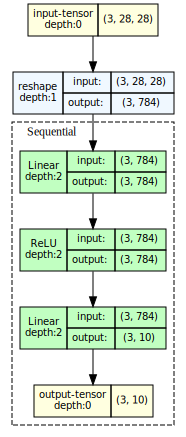

In [11]:
print("Network structure:")
print(simple_network)

print("Forward kernel schema:")
model_graph = src.utils.model_visualisation.draw_forward_kernel_graph(simple_network)
model_graph.visual_graph


# Task 3: Create the Loss Function, Optimizer, Scheduler, and Metric


## Goal

Now that we have prepared the dataset and the network, we need the remaining pieces for model training:
- a dictionary of batch-level loss functions;
- an optimizer;
- a learning-rate scheduler;
- a dictionary of batch-level metric functions.

## Training-Loop Contract

The training loop in [src/train_loop.py](../../../../src/train_loop.py) calls `model(batch)`, then evaluates every function in the `losses` dictionary and every function in the `metrics` dictionary. Therefore the loss and metric functions should read the same nested batch keys that the model writes.

## Components To Create

Use the following components:
- `loss(batch)`: define the cross-entropy loss between `batch['signals']['output']` and `batch['data']['label']`. Keep logits shaped as `[batch, n_classes]`; only flatten labels if needed.
- `losses`: create a dictionary that maps the loss name `'ce'` to the `loss` function. During training, the loop sums all named losses into one scalar for backpropagation, while keeping the individual named losses for progress bars, history, and MLflow logging.
- `accuracy(batch)`: define accuracy, compare `batch['postprocessed']['class']` with `batch['data']['label']`, and return `(enumerator, denominator)` so the loop can aggregate the metric across batches. Enumerator should be the number of correct labels, while denominator should be the number of total samples in the batch.
- `metrics`: create a dictionary that maps the metric name `'accuracy'` to the `accuracy` function. The dictionary keys are used in MLflow metric names and in the returned history.
- `torch.optim.AdamW` with learning rate `1.0e-3` as the optimizer and it should be targeted on the model's parameters (get them with `model.parameters()`).
- `torch.optim.lr_scheduler.ReduceLROnPlateau` as the scheduler on top of the `optimizer`.

## Scope

Create these objects and functions in the cell below. Accuracy is the only metric in this task, and cross-entropy is the only loss, but the loop accepts any number of named losses and metrics that follow these conventions.


In [12]:
try:
    model
except NameError:
    from src.models.feedforward.simple_fcnn import SimpleFCNN
    model = SimpleFCNN()

def loss(batch):
    logits = batch['signals']['output']
    labels = batch['data']['label']
    return nn.functional.cross_entropy(logits, labels)

losses = {'ce': loss}

def accuracy(batch):
    preds = batch['postprocessed']['class']
    labels = batch['data']['label']
    correct = (preds == labels).sum()
    total = labels.numel()
    return correct, total

metrics = {'accuracy': accuracy}

optimizer = torch.optim.AdamW(model.parameters(), lr=1.0e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5)

In [13]:
#import torchmetrics
#
#def loss(batch):
#    return batch['signals']['output'].abs().sum()
#
#losses = {'ce': loss}
#
#def accuracy(batch):
#    return 0, 1
#
#metrics = {'accuracy': accuracy}
#optimizer = torch.optim.AdamW(model.parameters(), lr=1.0e-3)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5)
#
# ^^^ These variables should be set up in this task


In [14]:
import torch.nn as nn
answer['loss_names'] = list(losses.keys())
answer['metric_names'] = list(metrics.keys())

answer['optimizer_class'] = optimizer.__class__.__name__
answer['optimizer_defaults'] = optimizer.defaults
answer['optimizer_param_groups_count'] = len(optimizer.param_groups)
answer['optimizer_lrs'] = [group['lr'] for group in optimizer.param_groups]

answer['scheduler_class'] = scheduler.__class__.__name__
answer['scheduler_optimizer_class'] = scheduler.optimizer.__class__.__name__

answer['test_loss_val'] = {f_name: function(check_batch) for f_name, function in losses.items()}
answer['test_metrics_val'] = {f_name: function(check_batch) for f_name, function in metrics.items()}

print(losses)
print(optimizer)
print(scheduler)
print(metrics)


{'ce': <function loss at 0x74de8fae7600>}
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.01
)
{'accuracy': <function accuracy at 0x74de8fae76a0>}


# Task 4: Create DataLoaders

## Goal

Now it is time to start the training process.

First, turn the datasets into dataloaders. A dataloader creates mini-batches and can shuffle the data for us.

## Implementation Details

Use `torch.utils.data.DataLoader` to create training and validation dataloaders.

Important details:
- shuffle the training data;
- do not shuffle the validation data;
- use `drop_last=True` for the training dataloader so that all training batches have the same size;
- use the `batch_size` equal to 32


In [15]:
from tqdm import trange, tqdm
import os

batch_size = 32

train_dl = torch.utils.data.DataLoader(
    MNIST_train, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=True
)
valid_dl = torch.utils.data.DataLoader(
    MNIST_valid, 
    batch_size=batch_size, 
    shuffle=False
)

# ^^^ These variables should be set up in this task

# Sanity checking that the dataloaders work
train_batch = next(iter(train_dl))
valid_batch = next(iter(valid_dl))

pprint(train_batch)
pprint(valid_batch)

# Storing the answers
answer['train_batch'] = str(train_batch)
answer['valid_batch'] = str(valid_batch)

{'image': tensor[32, 28, 28] n=25088 (98Kb) x∈[-1.000, 1.000] μ=-0.742 σ=0.614,
 'label': tensor[32] i64 x∈[0, 9] μ=4.281 σ=2.932}
{'image': tensor[32, 28, 28] n=25088 (98Kb) x∈[-1.000, 1.000] μ=-0.763 σ=0.587,
 'label': tensor[32] i64 x∈[0, 9] μ=4.125 σ=3.098}


# Task 5: Create training loop

## Goal

First, let us outline the training loop. Your task is to complete the placeholder blocks in [src/train_loop.py](../../../../src/train_loop.py), including the small helper functions for named losses/metrics and the training/validation blocks inside `train_model`. This notebook prepares the model, data, loss dictionary, metric dictionary, optimizer, scheduler, and logger, then calls that function.

The goal of `train_model` is to train the network for `n_epochs`, evaluate it on the validation dataloader after each epoch, and return a `history` dictionary with averaged losses and metrics. The surrounding code in `src/train_loop.py` already creates the history dictionaries, accumulators, MLflow logging calls, scheduler step, and return value. You only need to fill in the `## YOUR CODE HERE` regions; the surrounding progress bars, history dictionaries, scheduler step, MLflow logging, and return value are already wired up.

## Where You Will Work

You will work in two places:
1. In this notebook, define `losses`, `metrics`, `optimizer`, and `scheduler`.
2. In `src/train_loop.py`, complete the placeholder blocks that compute named losses, sum them for backpropagation, update named metrics, and run train/validation steps.

## Experiment Logging

Real projects often log experiments with tools such as MLflow, TensorBoard, Weights & Biases, or Neptune. In this notebook, we will use MLflow because it can log runs locally without requiring an external account.

## Training Stages

Training usually runs for several epochs. Each epoch has two stages:
- training;
- validation.

## Batch Protocol

For every dataloader batch, the loop first wraps it into the course batch protocol:
```python
batch = {'data': original_batch}
```
Then the model reads `batch['data']`, writes logits to `batch['signals']['output']`, and writes class predictions to `batch['postprocessed']['class']`.

## Helper Placeholders

Before the main loop, implement the helper placeholders:
- `_compute_losses(losses, batch)` should return a dictionary with the same keys as `losses`, where each value is the result of applying that loss function to the batch.
- `_sum_losses(batch_losses)` should add all values in the named-loss dictionary into one scalar tensor used for backpropagation; the individual named losses remain available for progress bars, history, and MLflow logging.
- `_update_metric_totals(metric_totals, metrics, batch)` should call each metric function, receive `(enumerator, denominator)`, and add those values to the matching accumulator.

## Training Placeholder

In the training-stage placeholder, implement one mini-batch update. The code should:
1. Switch the model to training mode with `model.train()`.
2. Reset gradients with `optimizer.zero_grad()`.
3. Run `model(batch)`.
4. Compute all named losses with `_compute_losses(losses, batch)`.
5. Sum the named losses with `_sum_losses(loss_values)` and store the result in `batch['loss']`. Store the full dictionary in `batch['losses']`.
6. Run backpropagation with `loss_value.backward()`.
7. Update model parameters with `optimizer.step()`.
8. Update every metric in the `metrics` dictionary by calling `_update_metric_totals(train_metrics, metrics, batch)`. The surrounding code uses the named losses for history, progress bars, and MLflow logging.

## Validation Placeholder

In the validation-stage placeholder, implement one validation mini-batch pass. The code already runs inside `with torch.no_grad():`. It should switch the model to evaluation mode, run `model(valid_batch)`, compute all named validation losses, store `valid_batch['losses']` and the summed `valid_batch['loss']`, and update every metric in the `metrics` dictionary. Do not call `backward()` or `optimizer.step()` during validation.

## Epoch Outputs

At the end of each epoch, the loop appends averaged values to a history dictionary with keys `train_loss`, `valid_loss`, `train_metrics`, and `valid_metrics`; each value is itself a dictionary keyed by loss or metric name. If a scheduler is provided, it is stepped once per epoch. If an MLflow logger is provided, the loop logs per-batch named training losses, per-epoch named losses/metrics, and training curves.


/usr/local/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/07/04 23:41:34 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$G

[Open MLflow run with graphs](http://127.0.0.1:5000/#/experiments/682338566444037820/runs/90b933c0057442209a9a1ae976351dc4)

epochs:   0%|          | 0/3 [00:00<?, ?it/s]

batches:   0%|          | 0/1875 [00:00<?, ?it/s]

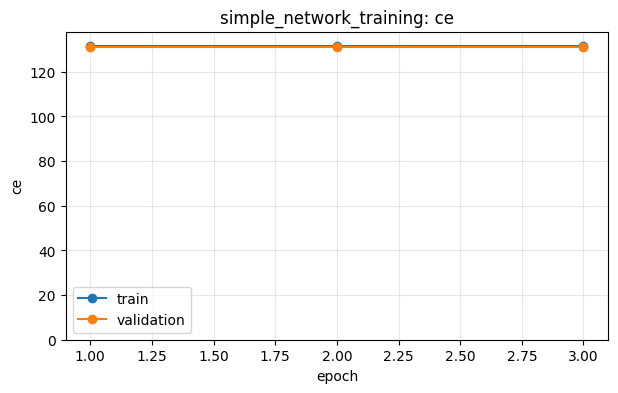

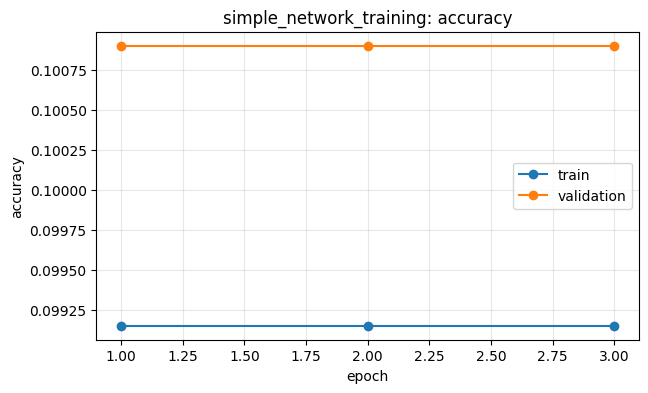

In [16]:
n_epochs = 3

training_logger = src.utils.mlflow.prepare_mlflow_logger('simple_network_training')

training_history = src.train_loop.train_model(
    simple_network,
    n_epochs,
    train_dl,
    valid_dl,
    losses,
    optimizer,
    metrics=metrics,
    scheduler=scheduler,
    mlflow_logger=training_logger,
    run_name='simple_network_training')

train_loss_history = training_history['train_loss']['ce']
valid_loss_history = training_history['valid_loss']['ce']
train_acc_history = training_history['train_metrics']['accuracy']
valid_acc_history = training_history['valid_metrics']['accuracy']

training_logger.end()


In [17]:
answer['train_loss_history'] = train_loss_history
answer['valid_loss_history'] = valid_loss_history
answer['train_acc_history'] = train_acc_history
answer['valid_acc_history'] = valid_acc_history

json_tricks.dump(utils.torch_to_numpy(answer), '.answer.json')


'{"seed_check": {"python.random": [0.8444218515250481, 0.7579544029403025, 0.420571580830845, 0.25891675029296335], "python.randint": [8, 7, 6, 4], "numpy.random.rand": {"__ndarray__": [[0.5488135039273248, 0.7151893663724195, 0.6027633760716439], [0.5448831829968969, 0.4236547993389047, 0.6458941130666561]], "dtype": "float64", "shape": [2, 3], "Corder": true}, "numpy.random.randn": {"__ndarray__": [[0.9500884175255894, -0.1513572082976979, -0.10321885179355784], [0.41059850193837233, 0.144043571160878, 1.454273506962975]], "dtype": "float64", "shape": [2, 3], "Corder": true}, "numpy.random.randint": {"__ndarray__": [[8, 1, 5], [9, 8, 9]], "dtype": "int64", "shape": [2, 3], "Corder": true}, "torch.rand": {"__ndarray__": [[0.49625658988952637, 0.7682217955589294, 0.08847743272781372], [0.13203048706054688, 0.30742281675338745, 0.6340786814689636]], "dtype": "float32", "shape": [2, 3], "Corder": true}, "torch.randn": {"__ndarray__": [[1.2644586563110352, -0.6874263882637024, 0.160381257

# Task 6: Experiment Time


## Goal

Now we have everything needed to train a network.

Create and train several models:
- a 1-layer FCNN, which is multiclass logistic regression;
- a 2-layer FCNN;
- a 3-layer FCNN.

## Epoch Count

The code below uses the current `n_epochs` value from the training-loop section. You can increase it later, for example to 100 epochs, when you want to run a longer experiment.

## Visualization

After training, visualize what the first linear layer has learned. Take the first-layer weight matrix, reshape selected rows into `28 x 28` images, plot them in the notebook, and log the figure to the corresponding MLflow run.


[Open MLflow run with graphs](http://127.0.0.1:5000/#/experiments/682338566444037820/runs/a60a500567024cc49a7812ddd9f62042)

epochs:   0%|          | 0/5 [00:00<?, ?it/s]

batches:   0%|          | 0/1875 [00:00<?, ?it/s]

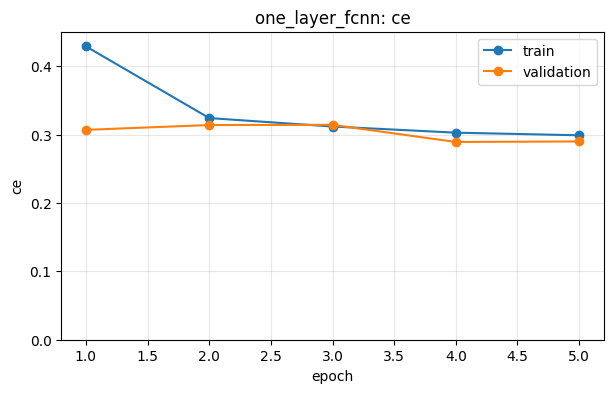

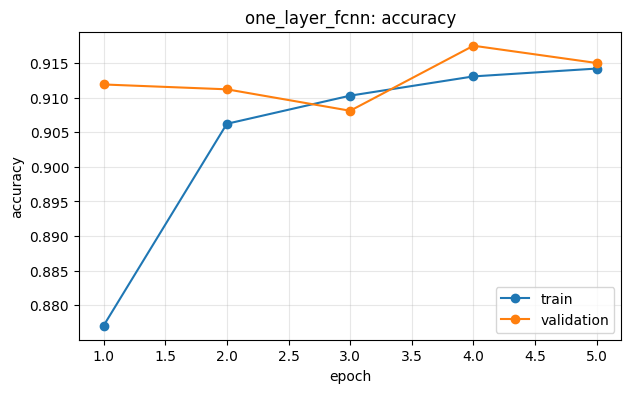

[Open MLflow run with graphs](http://127.0.0.1:5000/#/experiments/682338566444037820/runs/e6377d6ac86e4c3bb59a32ecb97a9c2d)

epochs:   0%|          | 0/5 [00:00<?, ?it/s]

batches:   0%|          | 0/1875 [00:00<?, ?it/s]

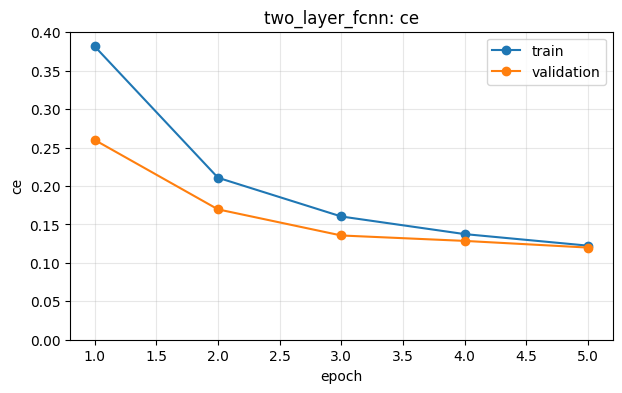

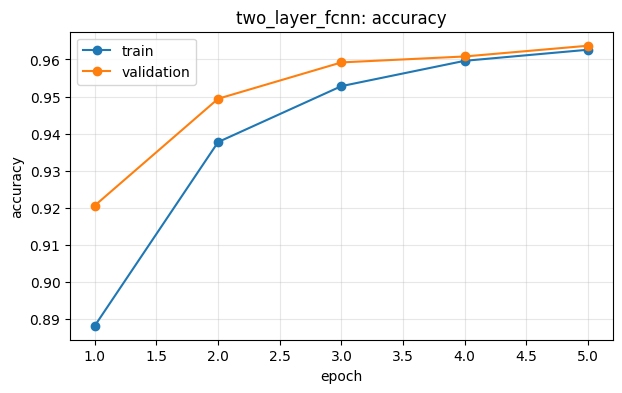

[Open MLflow run with graphs](http://127.0.0.1:5000/#/experiments/682338566444037820/runs/767d26c15e104543a0c78dac79a92fde)

epochs:   0%|          | 0/5 [00:00<?, ?it/s]

batches:   0%|          | 0/1875 [00:00<?, ?it/s]

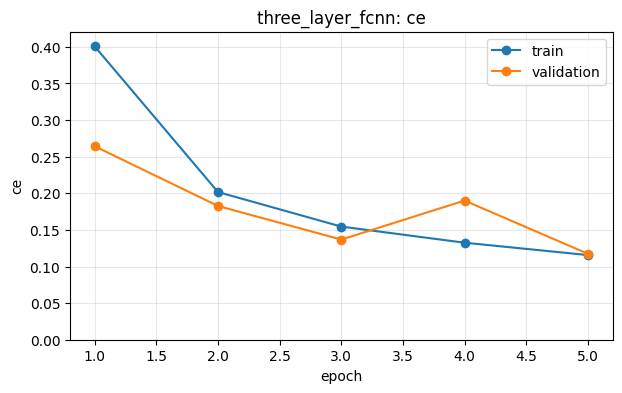

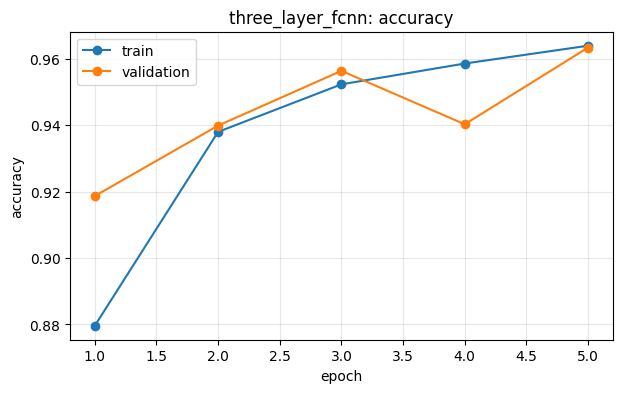

In [20]:
def run_fcnn_experiment(run_name, model, n_epochs=5):
    experiment_optimizer = torch.optim.AdamW(model.parameters(), lr=1.0e-3)
    experiment_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(experiment_optimizer)
    experiment_logger = src.utils.mlflow.prepare_mlflow_logger(run_name)
    history = src.train_loop.train_model(
        model,
        n_epochs,
        train_dl,
        valid_dl,
        losses,
        experiment_optimizer,
        metrics=metrics,
        scheduler=experiment_scheduler,
        mlflow_logger=experiment_logger,
        run_name=run_name)
    experiment_logger.end()
    return history

one_layer_fcnn = src.models.feedforward.simple_fcnn.SimpleFCNN(
    [28 * 28],
    n_classes=10,
    activation=torch.nn.LeakyReLU)

## YOUR CODE HERE

# UNCOMMENT THIS TO ENABLE THE EXPERIMENT

one_layer_fcnn = SimpleFCNN([], n_classes=10, activation=torch.nn.LeakyReLU)

two_layer_fcnn = SimpleFCNN([64], n_classes=10, activation=torch.nn.LeakyReLU)

three_layer_fcnn = SimpleFCNN([64, 32], n_classes=10, activation=torch.nn.LeakyReLU)


one_layer_history = run_fcnn_experiment('one_layer_fcnn', one_layer_fcnn)
two_layer_history = run_fcnn_experiment('two_layer_fcnn', two_layer_fcnn)
three_layer_history = run_fcnn_experiment('three_layer_fcnn', three_layer_fcnn)


In [21]:
import matplotlib.pyplot as plt

def first_weight_matrix(model):
    for module in model.modules():
        if isinstance(module, torch.nn.Linear):
            return module.weight
    raise ValueError('The model does not contain a linear layer.')


def plot_first_layer_weights(model, title, logger=None, max_images=10):
    weights = first_weight_matrix(model).detach().cpu()
    if weights.shape[1] != 28 * 28:
        raise ValueError('The first linear layer cannot be reshaped into 28 x 28 images.')

    n_images = min(max_images, weights.shape[0])
    n_cols = min(5, n_images)
    n_rows = (n_images + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 2.2 * n_rows))
    axes = np.asarray(axes).reshape(-1)

    for index in range(n_images):
        axes[index].imshow(weights[index].reshape(28, 28), cmap='grey')
        axes[index].set_title(f'unit {index}')
        axes[index].axis('off')

    for index in range(n_images, len(axes)):
        axes[index].axis('off')

    fig.suptitle(title)
    fig.tight_layout()

    if logger is not None:
        logger.log_figure(fig, 'figures/first_layer_weights.png')
    plt.show()
    plt.close(fig)
    # return fig


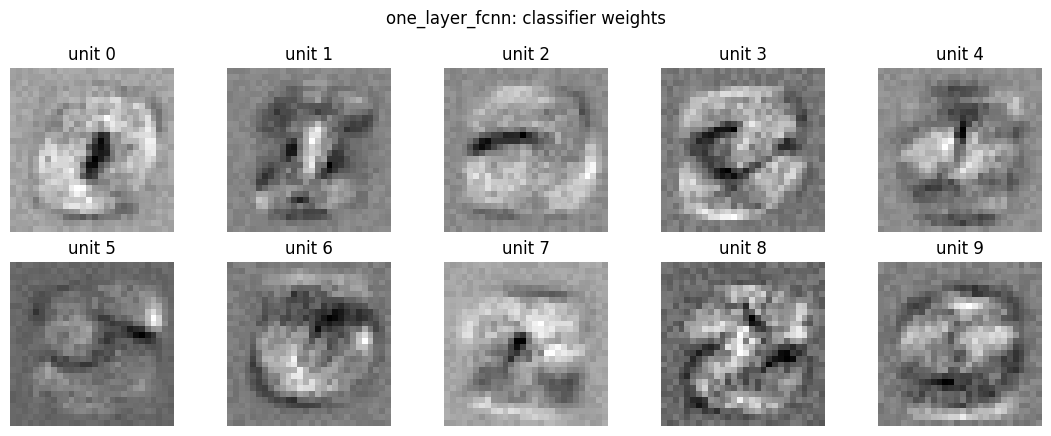

In [22]:
plot_first_layer_weights(one_layer_fcnn, 'one_layer_fcnn: classifier weights')


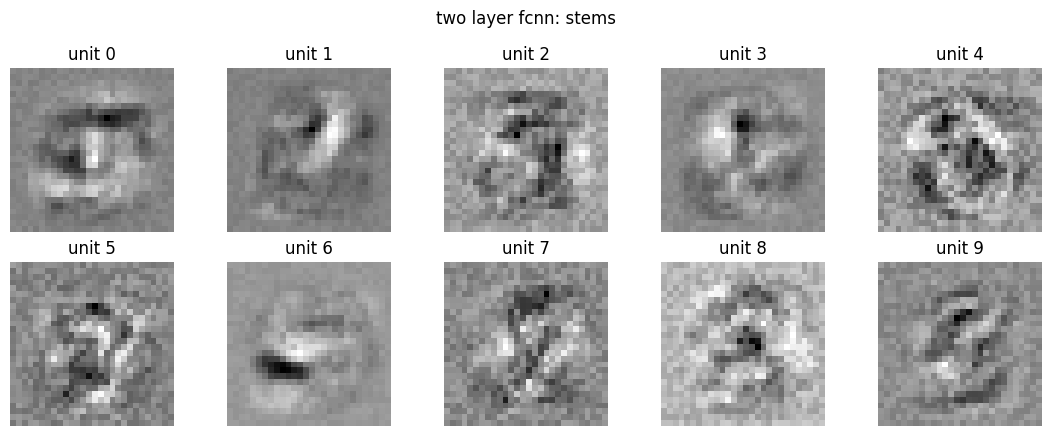

In [23]:
plot_first_layer_weights(two_layer_fcnn, 'two layer fcnn: stems')

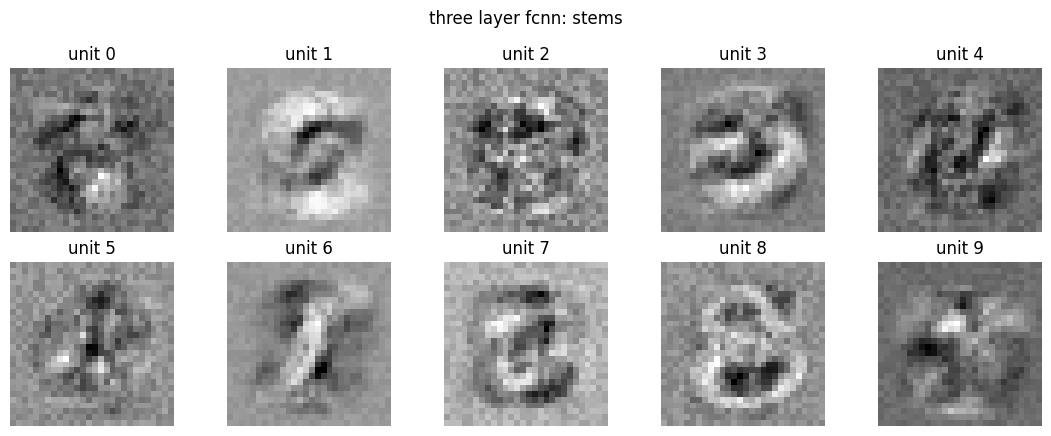

In [24]:
plot_first_layer_weights(three_layer_fcnn, 'three layer fcnn: stems')

# Long Run

!!! DO NOT CHECK THIS PART !!!

(in case you do, this training will be included in checks and the ckecks will take a very long time)

## Goal

Now run your experiments, 100 epochs each with each of the networks above.


In [ ]:
## YOUR CODE HERE
# Create fresh networks from the above (1, 2, 3 layers)
# Run experiment for 100 epochs
# Watch the trianing graphs
# Visualize stem layer



In [ ]:
# plot_first_layer_weights(one_layer_fcnn, 'one_layer_fcnn: classifier weights')
# plot_first_layer_weights(two_layer_fcnn, 'two layer fcnn: stems')
# plot_first_layer_weights(three_layer_fcnn, 'three layer fcnn: stems')

# Time to Think

## Convergence

What converges faster?
- 1-layer NN, also known here as multiclass logistic regression;
- 2-layer NN;
- 3-layer NN.

Would you expect a deeper network, for example 10 layers, to train better or worse with this simple setup?

## Interpreting Learned Patterns

What do the patterns from the 1-layer model resemble? Should they look like digit templates?

What do the first-layer patterns from the 2-layer and 3-layer models resemble? Should they be as directly interpretable as the 1-layer weights?


# Task 7 (Optional): More Experiments

## Activation Functions

Try training the networks above with different activation functions. Focus on the 2-layer network first:
- `Sigmoid`
- `Tanh`
- `ReLU`
- `LeakyReLU` <- good default option
- `SiLU` (also known as Swish)
- `GELU` (Gaussian Linear Unit, usually used in LLMs)

## Optimizers

Try different optimizers:
- `AdamW` <- this optimizer is usually considered as a baseline optimizer with learning rate `1.0e-3 -- 1.0e-4`
- `SGD` <- classical, but tricky one

Which optimizer is easier to tune?

## Longer Runs And Batch Sizes

If you have access to Google Colab or another machine with a GPU, try training for longer. Also try different batch sizes. Batch sizes are often selected as powers of 2:
- 2
- 4
- 8
- 16
- 32 <- this batch is usually considered as good enough, but still increasing it won't hurt
- 64
- etc.

## Discussion

Share your best recipe and discuss what improved your results.
